In [ ]:
from pathlib import Path
import osmnx as ox
import geopandas as gpd

RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Pull Manhattan drivable network
G = ox.graph_from_place(
    "Manhattan, New York City, New York, USA",
    network_type="drive"
)

# Convert to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

# Inspect what you have
print(edges.columns.tolist())
print(edges['highway'].value_counts())
print(f"Total edges: {len(edges)}")

# Save to file (repo-level data/raw, not notebooks/data/raw)
edges.to_file(RAW_DIR / "manhattan_roads.gpkg", driver="GPKG")
nodes.to_file(RAW_DIR / "manhattan_nodes.gpkg", driver="GPKG")

In [2]:
from pathlib import Path
import urllib.request

import pandas as pd

# TLC parquet endpoints (same CDN linked from NYC Open Data / TLC trip record pages)
FHVHV_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2025-06.parquet"
ZONE_LOOKUP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

RAW_PATH = Path("../data/raw/fhvhv_tripdata_2025-06.parquet")
OUT_PATH = Path("../data/processed/fhvhv_tripdata_2025-06_manhattan_pu.parquet")
DESKTOP_RAW = Path(r"C:\Users\Arv\OneDrive\Desktop\Raw Taxi\fhvhv_tripdata_2025-06.parquet")


def download_file(url: str, dest: Path) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {url} -> {dest}")
    urllib.request.urlretrieve(url, dest)
    print("Download complete.")


def ensure_raw_parquet(path: Path) -> Path:
    if path.exists():
        print(f"Using cached raw file: {path}")
        return path
    if DESKTOP_RAW.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Copying existing local file -> {path}")
        path.write_bytes(DESKTOP_RAW.read_bytes())
        return path
    download_file(FHVHV_URL, path)
    return path


ensure_raw_parquet(RAW_PATH)

# Official TLC taxi zone lookup: Borough == Manhattan -> PULocationID values
zones = pd.read_csv(ZONE_LOOKUP_URL)
manhattan_pu_ids = zones.loc[zones["Borough"] == "Manhattan", "LocationID"].astype("int32")
print(f"Manhattan pickup zones: {len(manhattan_pu_ids)} LocationIDs")

df = pd.read_parquet(RAW_PATH)
df_manhattan = df[df["PULocationID"].isin(manhattan_pu_ids)].copy()

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_manhattan.to_parquet(OUT_PATH, index=False)

print(f"All trips: {len(df):,}")
print(f"Manhattan pickups: {len(df_manhattan):,}")
print(f"Saved -> {OUT_PATH.resolve()}")
print(df_manhattan.dtypes)
df_manhattan.head()


Using cached raw file: ..\data\raw\fhvhv_tripdata_2025-06.parquet
Manhattan pickup zones: 69 LocationIDs
All trips: 19,868,009
Manhattan pickups: 7,122,571
Saved -> C:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\processed\fhvhv_tripdata_2025-06_manhattan_pu.parquet
hvfhs_license_num                  str
dispatching_base_num               str
originating_base_num               str
request_datetime        datetime64[us]
on_scene_datetime       datetime64[us]
pickup_datetime         datetime64[us]
dropoff_datetime        datetime64[us]
PULocationID                     int32
DOLocationID                     int32
trip_miles                     float64
trip_time                        int64
base_passenger_fare            float64
tolls                          float64
bcf                            float64
sales_tax                      float64
congestion_surcharge           float64
airport_fee                    float64
tips                           float64
driver_pay                

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
1,HV0003,B03404,B03404,2025-05-31 23:57:57,2025-06-01 00:00:11,2025-06-01 00:00:57,2025-06-01 00:17:59,158,148,2.23,...,2.75,0.0,0.00,31.74,N,N,N,N,N,1.5
2,HV0003,B03404,B03404,2025-06-01 00:18:38,2025-06-01 00:18:51,2025-06-01 00:20:38,2025-06-01 00:31:24,148,234,1.71,...,2.75,0.0,0.00,17.82,N,N,N,N,N,1.5
3,HV0003,B03404,B03404,2025-06-01 00:35:39,2025-06-01 00:38:07,2025-06-01 00:39:19,2025-06-01 01:15:15,234,174,15.50,...,2.75,0.0,13.51,61.83,N,N,N,N,N,1.5
4,HV0003,B03404,B03404,2025-06-01 00:01:55,2025-06-01 00:03:41,2025-06-01 00:05:42,2025-06-01 00:21:52,243,116,2.60,...,0.00,0.0,0.00,15.03,N,N,N,N,N,0.0
5,HV0003,B03404,B03404,2025-06-01 00:16:35,2025-06-01 00:27:49,2025-06-01 00:28:50,2025-06-01 00:45:51,152,74,2.65,...,0.00,0.0,0.00,9.45,Y,Y,N,N,N,0.0


## Yellow Taxi January 2010 (lat/lon coordinates)

Pre-2011 yellow trip records include raw pickup/dropoff longitude and latitude. Tries parquet first, then CSV if the parquet download fails.

In [5]:
from pathlib import Path
import urllib.error
import urllib.request

import pandas as pd

YELLOW_PARQUET_URL = (
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2010-01.parquet"
)
YELLOW_CSV_URL = (
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2010-01.csv"
)

RAW_PARQUET = Path("../data/raw/yellow_tripdata_2010-01.parquet")
RAW_CSV = Path("../data/raw/yellow_tripdata_2010-01.csv")

COORD_COLS = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
]


def download_file(url: str, dest: Path) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {url} -> {dest}")
    urllib.request.urlretrieve(url, dest)
    print("Download complete.")


def load_yellow_2010() -> pd.DataFrame:
    if RAW_PARQUET.exists():
        print(f"Using cached parquet: {RAW_PARQUET}")
        return pd.read_parquet(RAW_PARQUET)

    try:
        download_file(YELLOW_PARQUET_URL, RAW_PARQUET)
        return pd.read_parquet(RAW_PARQUET)
    except (urllib.error.URLError, urllib.error.HTTPError, OSError) as err:
        print(f"Parquet download failed ({err}); trying CSV...")

    if RAW_CSV.exists():
        print(f"Using cached CSV: {RAW_CSV}")
    else:
        download_file(YELLOW_CSV_URL, RAW_CSV)

    return pd.read_csv(RAW_CSV, low_memory=False)


df_2010 = load_yellow_2010()

print("Column names:")
print(list(df_2010.columns))
print(f"\nShape: {df_2010.shape}")

present = [c for c in COORD_COLS if c in df_2010.columns]
missing = [c for c in COORD_COLS if c not in df_2010.columns]
print(f"\nCoordinate columns present: {present or '(none)'}")
print(f"Coordinate columns missing: {missing or '(none)'}")

if missing:
    print("\nReal non-zero coordinates: not available (columns missing).")
else:
    valid_pickup = (
        df_2010["pickup_longitude"].notna()
        & df_2010["pickup_latitude"].notna()
        & (df_2010["pickup_longitude"] != 0)
        & (df_2010["pickup_latitude"] != 0)
    )
    valid_dropoff = (
        df_2010["dropoff_longitude"].notna()
        & df_2010["dropoff_latitude"].notna()
        & (df_2010["dropoff_longitude"] != 0)
        & (df_2010["dropoff_latitude"] != 0)
    )

    print(
        f"\nReal non-zero pickup coordinates exist: {valid_pickup.any()} "
        f"({100 * valid_pickup.mean():.2f}% of rows)"
    )
    print(
        f"Real non-zero dropoff coordinates exist: {valid_dropoff.any()} "
        f"({100 * valid_dropoff.mean():.2f}% of rows)"
    )

    has_coords = valid_pickup & valid_dropoff
    print("\nSample (5 rows) — coordinate columns:")
    if has_coords.any():
        print(df_2010.loc[has_coords, COORD_COLS].head(5).to_string())
    else:
        print("(no rows with valid pickup and dropoff coordinates)")

Using cached parquet: ..\data\raw\yellow_tripdata_2010-01.parquet
Column names:
['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'rate_code', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'surcharge', 'mta_tax', 'tip_amount', 'tolls_amount', 'total_amount']

Shape: (14863778, 18)

Coordinate columns present: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
Coordinate columns missing: (none)

Real non-zero pickup coordinates exist: True (98.19% of rows)
Real non-zero dropoff coordinates exist: True (98.23% of rows)

Sample (5 rows) — coordinate columns:
   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude
0        -73.956778        40.767750         -73.965957         40.765232
1        -73.996118        40.763932         -73.981512         40.741193
2        -73.979673        40.783790         -73.917852     

Shape before filtering: (14863778, 18)
Shape after filtering:  (14001836, 18)
% of original data retained: 94.20%

Pickup coordinate ranges after filtering:
  pickup_longitude: -74.047892 to -73.906700
  pickup_latitude:  40.682900 to 40.881995

Saved -> C:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\processed\tlc_2010_manhattan_pickups.parquet


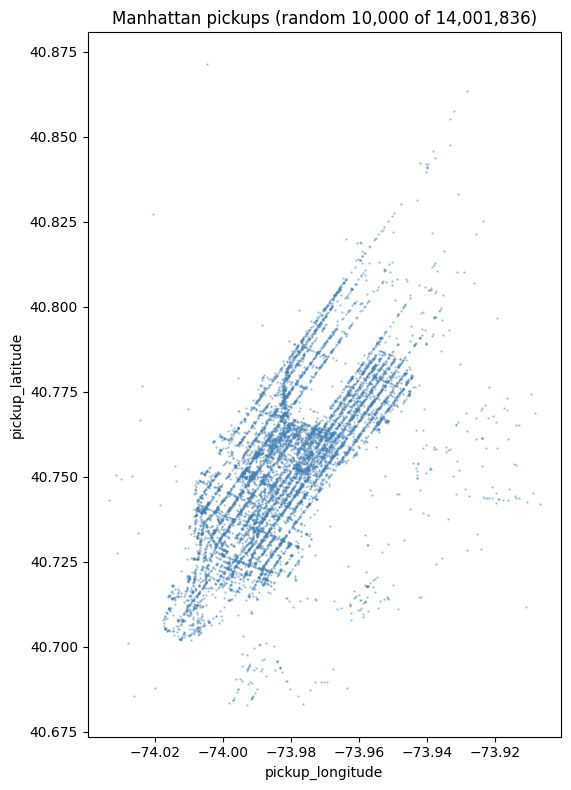

In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

OUT_PATH_2010 = Path("../data/processed/tlc_2010_manhattan_pickups.parquet")

LON_MIN, LON_MAX = -74.0479, -73.9067
LAT_MIN, LAT_MAX = 40.6829, 40.8820

n_before = len(df_2010)

valid_pickup = (
    df_2010["pickup_longitude"].notna()
    & df_2010["pickup_latitude"].notna()
    & (df_2010["pickup_longitude"] != 0)
    & (df_2010["pickup_latitude"] != 0)
)

in_bbox = (
    df_2010["pickup_longitude"].between(LON_MIN, LON_MAX)
    & df_2010["pickup_latitude"].between(LAT_MIN, LAT_MAX)
)

df_mht_pu = df_2010.loc[valid_pickup & in_bbox].copy()
n_after = len(df_mht_pu)

print(f"Shape before filtering: {df_2010.shape}")
print(f"Shape after filtering:  {df_mht_pu.shape}")
print(f"% of original data retained: {100 * n_after / n_before:.2f}%")

print("\nPickup coordinate ranges after filtering:")
print(
    f"  pickup_longitude: {df_mht_pu['pickup_longitude'].min():.6f} "
    f"to {df_mht_pu['pickup_longitude'].max():.6f}"
)
print(
    f"  pickup_latitude:  {df_mht_pu['pickup_latitude'].min():.6f} "
    f"to {df_mht_pu['pickup_latitude'].max():.6f}"
)

gdf_mht_pu = gpd.GeoDataFrame(
    df_mht_pu,
    geometry=gpd.points_from_xy(
        df_mht_pu["pickup_longitude"],
        df_mht_pu["pickup_latitude"],
    ),
    crs="EPSG:4326",
)
gdf_mht_pu = gdf_mht_pu.to_crs("EPSG:2263")

# Parquet is written after borough-boundary clip in the next cell
print(f"\nReady for borough clip ({n_after:,} bbox-filtered pickups in memory)")

sample_n = min(10_000, len(df_mht_pu))
sample = df_mht_pu.sample(n=sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(
    sample["pickup_longitude"],
    sample["pickup_latitude"],
    s=0.5,
    alpha=0.4,
    c="steelblue",
)
ax.set_title(f"Manhattan pickups (random {sample_n:,} of {n_after:,})")
ax.set_xlabel("pickup_longitude")
ax.set_ylabel("pickup_latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Clip 2010 pickups to Manhattan borough boundary

Bounding-box filtering keeps points in rivers and in Brooklyn/Queens/Bronx. Download the official NYC Manhattan borough polygon, reproject pickups and boundary to **EPSG:2263**, spatial-join `within`, then overwrite the processed parquet.

Shape before spatial join: (13642660, 19)
Shape after spatial join:  (13642660, 19)
Rows removed: 0 (0.00%)

Overwritten -> C:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\processed\tlc_2010_manhattan_pickups.parquet


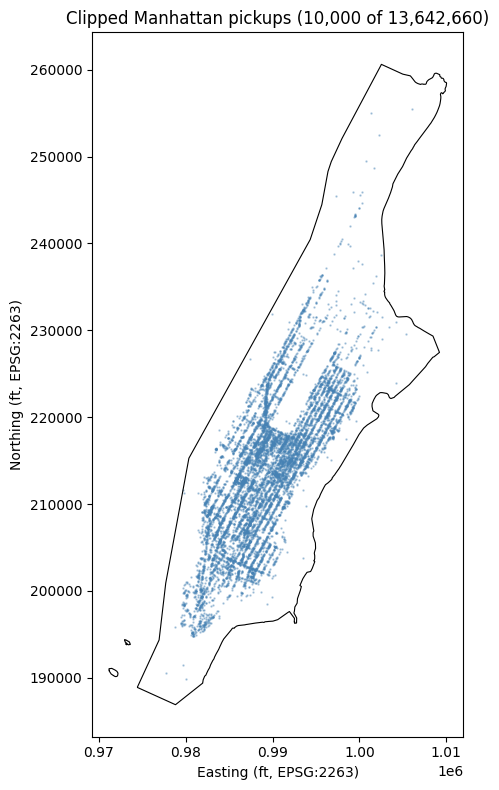

In [ ]:
import json
import urllib.request
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

TARGET_CRS = "EPSG:2263"
OUT_PATH_2010 = Path("../data/processed/tlc_2010_manhattan_pickups.parquet")

# ArcGIS layer backing NYC Open Data "Borough Boundaries" (request GeoJSON in EPSG:2263)
BOROUGH_QUERY_URL = (
    "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/"
    "NYC_Borough_Boundary/FeatureServer/0/query"
    "?where=BoroName%3D%27Manhattan%27&outFields=*&f=geojson&outSR=2263"
)


def load_manhattan_boundary(crs: str) -> gpd.GeoDataFrame:
    try:
        with urllib.request.urlopen(BOROUGH_QUERY_URL, timeout=120) as resp:
            payload = json.load(resp)
        boundary = gpd.GeoDataFrame.from_features(payload["features"], crs=crs)
        print(f"Loaded Manhattan borough boundary from NYC Open Data ({len(boundary)} polygon)")
        return boundary
    except Exception as err:
        print(f"NYC Open Data download failed ({err}); falling back to OSM via osmnx")
        boundary = ox.geocode_to_gdf("Manhattan, New York City, New York, USA")
        return boundary.to_crs(crs)


# Pickups: in-memory from bbox cell, else parquet
if "gdf_mht_pu" in globals():
    gdf_mht_pu = globals()["gdf_mht_pu"]
else:
    gdf_mht_pu = gpd.read_parquet(OUT_PATH_2010)

# Force both layers to the same projected CRS (feet)
gdf_mht_pu = gdf_mht_pu.to_crs(TARGET_CRS)
manhattan_boundary = load_manhattan_boundary(TARGET_CRS)

n_before = len(gdf_mht_pu)

gdf_mht_pu_clean = gpd.sjoin(
    gdf_mht_pu,
    manhattan_boundary[["geometry"]],
    how="inner",
    predicate="within",
)
gdf_mht_pu_clean = gdf_mht_pu_clean.drop(
    columns=[c for c in gdf_mht_pu_clean.columns if c.startswith("index_")],
    errors="ignore",
)

n_after = len(gdf_mht_pu_clean)
print(f"Pickups CRS: {gdf_mht_pu.crs}")
print(f"Boundary CRS: {manhattan_boundary.crs}")
print(f"Shape before spatial join: ({n_before:,}, {gdf_mht_pu.shape[1]})")
print(f"Shape after spatial join:  ({n_after:,}, {gdf_mht_pu_clean.shape[1]})")
print(
    f"Rows removed: {n_before - n_after:,} "
    f"({100 * (n_before - n_after) / n_before:.2f}%)"
)

gdf_mht_pu = gdf_mht_pu_clean
OUT_PATH_2010.parent.mkdir(parents=True, exist_ok=True)
gdf_mht_pu.to_parquet(OUT_PATH_2010)
print(f"\nOverwritten -> {OUT_PATH_2010.resolve()}")

sample_n = min(10_000, len(gdf_mht_pu))
sample = gdf_mht_pu.sample(n=sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(6, 8))
manhattan_boundary.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=2)
sample.plot(ax=ax, markersize=0.5, alpha=0.4, color="steelblue", zorder=1)
ax.set_title(f"Clipped Manhattan pickups ({sample_n:,} of {n_after:,})")
ax.set_xlabel("Easting (ft, EPSG:2263)")
ax.set_ylabel("Northing (ft, EPSG:2263)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## NYC Open Data constraint layers (Manhattan bbox)

Download bus stop shelters, fire hydrants, bike lanes, and parking regulation signs (loading / no standing) via the Socrata API, clip to the Manhattan bounding box where needed, reproject to **EPSG:2263**, and save GeoPackages under `data/raw/`.

**Dataset notes**
- **Bus Stop Shelters** — [NYC Open Data `t4f2-8md7`](https://data.cityofnewyork.us/Transportation/Bus-Stop-Shelters/t4f2-8md7); Manhattan rows filtered by `boro_name`. Replaces MTA `2ucp-7wg5` and the retired NYC `erm2-nwe9` endpoint.
- **Bike routes** — use `mzxg-pwib` (`s5uu-3ajy` was retired).
- **Parking regulations** — use `nfid-uabd` (Parking Regulation Locations and Signs); `pvqr-7yc4` is parking violations, not sign geometry.

Implementation lives in `src/download_nyc_layers.py`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.download_nyc_layers import download_all

layers = download_all(PROJECT_ROOT / "data/raw")


[bus_stops] MTA Bus Stops (NY State Open Data; not on data.cityofnewyork.us)

=== bus_stops ===
shape: (880483, 21)
crs: EPSG:2263
geometry type: {'Point': 880483}
                         geometry               valid_from  \
0  POINT (1007305.031 259611.979)  2019-02-17T00:00:00.000   
1  POINT (1006071.998 245439.516)  2019-02-17T00:00:00.000   

                  valid_to in_effect route_id route_short_name  \
0  2019-03-05T00:00:00.000     false    BXM18            BxM18   
1  2019-03-05T00:00:00.000     false     BX11             Bx11   

                             route_long_name  \
0                       Riverdale - Downtown   
1  West Farms Rd - Southern Blvd & GW Bridge   

                         route_description route_color stop_id  ...  \
0  Via Riverdale / H. Hudsn / Bway & Trnty      00933C  100676  ...   
1          via Claremont Pkwy / E 170th St      FAA61A  100773  ...   

  direction_id direction revenue_stop timepoint boarding alighting is_cbd  \
0            